# Quick feature extraction sandbox

Notebook goal for now:

- make simple colored-square images
- pull layer features from one vision model
- normalize features
- save everything to `results/vision/`

No DAM in this notebook yet.

In [10]:
%pip install torch torchvision timm

python(34106) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


In [11]:
# Small sanity check so this fails fast if kernel deps are missing.
import importlib.util

required = ["torch", "torchvision", "timm"]
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
if missing:
    raise ModuleNotFoundError(
        f"Missing in this kernel: {missing}. Run: %pip install torch torchvision timm"
    )
print("deps ok")

deps ok


In [12]:
from pathlib import Path
import json
import numpy as np
from PIL import Image

from vision.image_generator import (
    build_preview_grid,
    generate_square_stimuli,
    metadata_to_dicts,
)
from vision.model_wrapper import VisionEmbeddingWrapper
from vision.feature_preprocess import LayerwisePreprocessor

In [20]:
# Quick knobs
# MODEL_NAME can take any of the following values:
# vit_base_patch16_224
# vit_small_patch16_224
# vit_large_patch16_224
# deit_small_patch16_224
# deit_base_patch16_224
# resnet50
# convnext_base
# efficientnet_b0
MODEL_NAME = "vit_base_patch16_224"
USE_PRETRAINED = True  # use pretrained weights or randomly initialized weights?
DEVICE = "cpu"
N_PER_COLOR = 3
BATCH_SIZE = 8
SEED = 0

OUTPUT_DIR = Path("results/vision")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

images, metadata = generate_square_stimuli(
    n_per_color=N_PER_COLOR,
    image_size=224,
    square_size=20,
    fixed_position=False,
    seed=SEED,
)

print("n_images:", len(images))
metadata[:2]

n_images: 18


[StimulusRecord(stimulus_id='red_0000', color_name='red', color_rgb=(220, 20, 60), x=174, y=130, image_size=224, square_size=20),
 StimulusRecord(stimulus_id='red_0001', color_name='red', color_rgb=(220, 20, 60), x=104, y=55, image_size=224, square_size=20)]

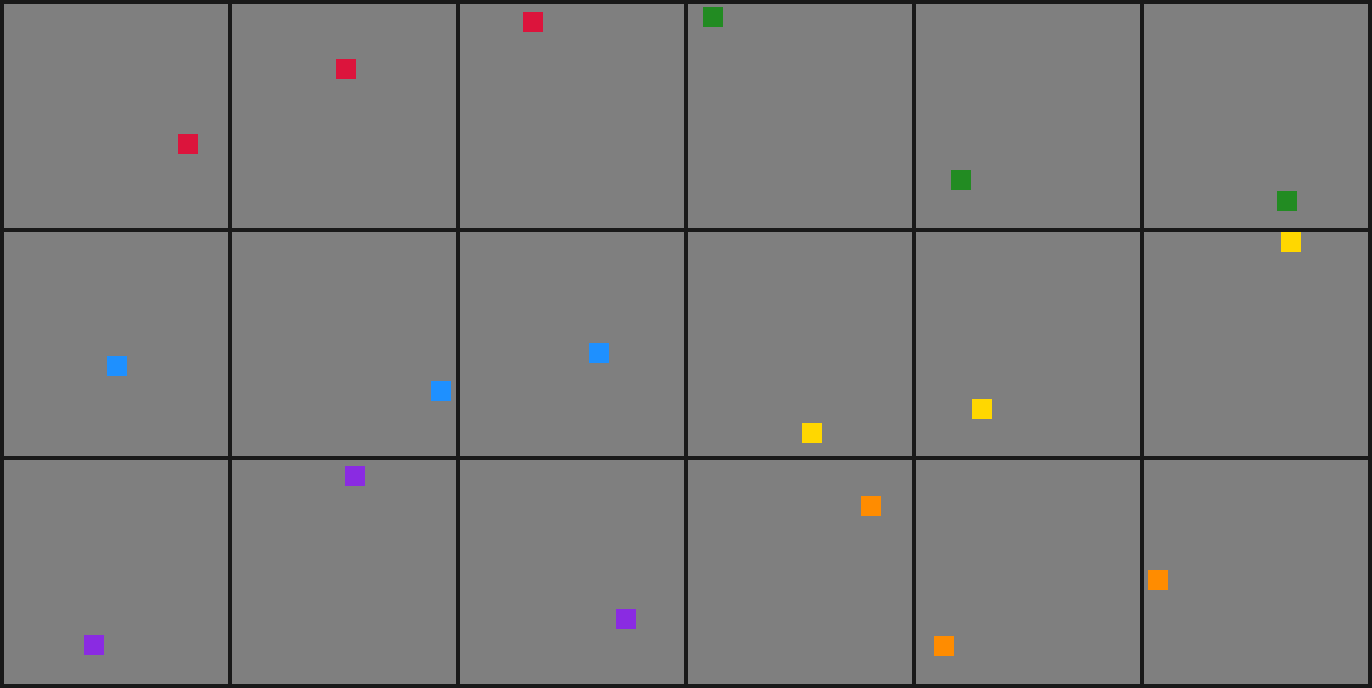

In [21]:
preview = build_preview_grid(images[:18], ncols=6)
preview_path = OUTPUT_DIR / f"preview_notebook_{MODEL_NAME}.png"
preview.save(preview_path)
preview

In [23]:
wrapper = VisionEmbeddingWrapper(
    model_name=MODEL_NAME,
    pretrained=USE_PRETRAINED,
    device=DEVICE,
    pooling="auto",
)

features_raw = wrapper.extract(images, batch_size=BATCH_SIZE)
prep = LayerwisePreprocessor(use_zscore=True, l2_normalize=True)
features = prep.fit_transform(features_raw)

{k: v.shape for k, v in features.items()}

{'layer_0': (18, 768), 'layer_6': (18, 768), 'layer_11': (18, 768)}

- Fix the position, and vary the color.
- Fix the color, and vary the position.
- Vary both
Normalize both of the spatial and color dimensions. Color distance normalized + Euclidean distance in 2D normalized.
Cosine of the angle between colors on a color ring.
Normalized spaces will weigh both equally

In [9]:
npz_path = OUTPUT_DIR / f"features_notebook_{MODEL_NAME}.npz"
payload = {}
for layer_name, feats in features.items():
    payload[f"features_{layer_name}"] = feats
payload["stimulus_id"] = np.array([m.stimulus_id for m in metadata], dtype=object)
payload["color_name"] = np.array([m.color_name for m in metadata], dtype=object)
payload["x"] = np.array([m.x for m in metadata], dtype=np.int32)
payload["y"] = np.array([m.y for m in metadata], dtype=np.int32)
np.savez_compressed(npz_path, **payload)

metadata_json_path = OUTPUT_DIR / f"metadata_notebook_{MODEL_NAME}.json"
metadata_json_path.write_text(json.dumps(metadata_to_dicts(metadata), indent=2), encoding="utf-8")

print(f"Saved: {npz_path}")
print(f"Saved: {metadata_json_path}")
print(f"Saved: {preview_path}")

Saved: results/vision/features_notebook_vit_base_patch16_224.npz
Saved: results/vision/metadata_notebook_vit_base_patch16_224.json
Saved: results/vision/preview_notebook_vit_base_patch16_224.png
